In [88]:
import os
import glob
import json
import numpy as np
import pandas as pd
import numpy.typing as npt
import matplotlib.pyplot as plt
from IPython.display import Video
from scipy.spatial.transform import Rotation

from sklearn.model_selection import train_test_split
from scipy.signal import find_peaks
import seaborn as sb
import itertools


import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

#plt.style.use("seaborn-deep")

sb.set_palette("husl",3)
sb.set_style("whitegrid")

# Manual selection of classes from folders
# !!! For automatic processing all classes go to "Automatic" 

### Function to load data from single folder

In [89]:
def load_and_label_data(file_paths, label):
    """Load data from multiple CSV files and assign a label."""
    data_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        # The CSV contains 'ax', 'ay', 'az', 'q0', 'q1', 'q2', 'q3'
        df['label'] = label
        data_list.append(df)
    return pd.concat(data_list)

### Load front_raise data

In [321]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/front_raise/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))


51


In [322]:
completedf_front_raise = load_and_label_data(excersise_files, 'front_raise')

In [323]:
completedf_front_raise

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,3218930,5635.0,6881.0,-1727.0,0.337,0.637,0.048,0.692,front_raise
1,3218946,5313.0,7701.0,-877.0,0.305,0.642,0.099,0.696,front_raise
2,3218962,4893.0,6717.0,29.0,0.283,0.642,0.134,0.700,front_raise
3,3218979,4827.0,4741.0,317.0,0.267,0.641,0.155,0.703,front_raise
4,3219005,4985.0,2377.0,565.0,0.253,0.641,0.169,0.705,front_raise
...,...,...,...,...,...,...,...,...,...
251,8426827,-809.0,-698.0,8056.0,0.982,-0.032,0.055,-0.175,front_raise
252,8426844,-793.0,-638.0,8178.0,0.982,-0.032,0.055,-0.175,front_raise
253,8426861,-777.0,-710.0,8104.0,0.982,-0.032,0.055,-0.175,front_raise
254,8426877,-823.0,-680.0,8106.0,0.982,-0.032,0.055,-0.175,front_raise


### Load shoulder_press data

In [324]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/shoulder_press/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

100


In [325]:
completedf_shoulder_press = load_and_label_data(excersise_files, 'shoulder_press')

In [326]:
completedf_shoulder_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,359849,-2411.0,-2335.0,-96.0,0.621,-0.501,0.483,0.360,shoulder_press
1,359865,-2529.0,-2209.0,302.0,0.620,-0.502,0.483,0.362,shoulder_press
2,359884,-3037.0,-2081.0,538.0,0.618,-0.505,0.481,0.362,shoulder_press
3,359900,-2829.0,-2329.0,426.0,0.617,-0.508,0.480,0.361,shoulder_press
4,359916,-2679.0,-1649.0,490.0,0.616,-0.513,0.478,0.358,shoulder_press
...,...,...,...,...,...,...,...,...,...
1096,2044427,-5300.0,2470.0,523.0,0.599,0.641,0.258,-0.403,shoulder_press
1097,2044445,-5060.0,6294.0,-165.0,0.600,0.649,0.242,-0.400,shoulder_press
1098,2044463,-7382.0,8172.0,-675.0,0.606,0.653,0.227,-0.393,shoulder_press
1099,2044481,-5510.0,7266.0,381.0,0.615,0.656,0.208,-0.385,shoulder_press


### Load curl data

In [327]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/curl/"

excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(excersise_files))

101


In [328]:
completedf_curl = load_and_label_data(excersise_files, 'curl')

In [329]:
completedf_curl

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,6054558,2903.0,6634.0,3302.0,0.768,0.539,0.004,0.345,curl
1,6054584,2879.0,6724.0,3336.0,0.769,0.539,0.003,0.344,curl
2,6054600,3015.0,6726.0,3360.0,0.769,0.538,0.002,0.344,curl
3,6054617,3099.0,6792.0,3346.0,0.770,0.538,0.001,0.344,curl
4,6054634,3071.0,6660.0,3504.0,0.770,0.537,0.000,0.343,curl
...,...,...,...,...,...,...,...,...,...
1387,1339665,7772.0,3358.0,-2071.0,0.419,0.702,-0.303,0.490,curl
1388,1339682,8054.0,3138.0,-2023.0,0.433,0.691,-0.310,0.489,curl
1389,1339699,8078.0,2098.0,-1681.0,0.446,0.680,-0.317,0.488,curl
1390,1339716,7790.0,1818.0,-1307.0,0.457,0.671,-0.323,0.486,curl


### Load non_exercise data

In [330]:
PATH_TO_EXERCISE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/non_exersice/"

non_excersise_files = sorted(glob.glob(os.path.join(PATH_TO_EXERCISE_FOLDER, "*.csv")))
print(len(non_excersise_files))

606


In [357]:
completedf_non_exersice_press = load_and_label_data(non_excersise_files[:300], 'non_exersice')

In [358]:
completedf_non_exersice_press

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,2523787,3999.0,9000.0,1199.0,0.194,-0.010,-0.606,-0.771,non_exersice
1,2523803,4393.0,9074.0,1287.0,0.200,-0.014,-0.610,-0.766,non_exersice
2,2523819,4489.0,8628.0,1563.0,0.204,-0.018,-0.614,-0.763,non_exersice
3,2523845,4603.0,8662.0,1733.0,0.206,-0.021,-0.616,-0.760,non_exersice
4,2523861,4409.0,8104.0,1953.0,0.207,-0.023,-0.619,-0.758,non_exersice
...,...,...,...,...,...,...,...,...,...
843,7224795,-5034.0,-4868.0,1746.0,0.746,-0.312,0.541,-0.231,non_exersice
844,7224812,-4746.0,-4256.0,1838.0,0.741,-0.326,0.539,-0.234,non_exersice
845,7224829,-4700.0,-4886.0,1626.0,0.735,-0.341,0.537,-0.235,non_exersice
846,7224845,-4572.0,-5150.0,834.0,0.728,-0.358,0.536,-0.235,non_exersice


### Concatenate into one dataframe

In [359]:
df_concatenated = pd.concat([completedf_front_raise, completedf_shoulder_press, completedf_curl, completedf_non_exersice_press], ignore_index=True)

In [360]:
df_concatenated

,timeMs,ax,ay,az,q0,q1,q2,q3,label
0,3218930,5635.0,6881.0,-1727.0,0.337,0.637,0.048,0.692,front_raise
1,3218946,5313.0,7701.0,-877.0,0.305,0.642,0.099,0.696,front_raise
2,3218962,4893.0,6717.0,29.0,0.283,0.642,0.134,0.700,front_raise
3,3218979,4827.0,4741.0,317.0,0.267,0.641,0.155,0.703,front_raise
4,3219005,4985.0,2377.0,565.0,0.253,0.641,0.169,0.705,front_raise
...,...,...,...,...,...,...,...,...,...
545252,7224795,-5034.0,-4868.0,1746.0,0.746,-0.312,0.541,-0.231,non_exersice
545253,7224812,-4746.0,-4256.0,1838.0,0.741,-0.326,0.539,-0.234,non_exersice
545254,7224829,-4700.0,-4886.0,1626.0,0.735,-0.341,0.537,-0.235,non_exersice
545255,7224845,-4572.0,-5150.0,834.0,0.728,-0.358,0.536,-0.235,non_exersice


# Automatic dataset processing (skip if need Manual selection)

## Load all data in loop

In [61]:
def load_all_data(base_folder):
    """
    Load and label data from all exercise folders within a base folder.
    
    Parameters:
    - base_folder: The path to the base folder containing exercise subfolders.
    
    Returns:
    - A pandas DataFrame containing all data, labeled by exercise.
    """
    all_data_frames = []
    # List all subdirectories in the base folder
    for folder_name in os.listdir(base_folder):
        folder_path = os.path.join(base_folder, folder_name)
        if os.path.isdir(folder_path):
            exercise_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
            # Use the folder name as the label
            df_labeled = load_and_label_data(exercise_files, folder_name)
            all_data_frames.append(df_labeled)
    
    # Concatenate all DataFrames, ignoring index to reset it in the final DataFrame
    df_concatenated = pd.concat(all_data_frames, ignore_index=True)
    return df_concatenated

In [62]:
BASE_FOLDER = "../DMP_9D_ACCEL_Logs/cleaned/"

df_concatenated = load_all_data(BASE_FOLDER)

# Training section
df_concatenated is dataframe build during Manual or Automatic data preparation stages.

In [361]:
df_concatenated.shape

(545257, 9)

In [362]:
unique_classes = df_concatenated['label'].unique()
print(unique_classes.shape)

(4,)


In [363]:
unique_classes_counts = df_concatenated['label'].value_counts()
print(unique_classes_counts)

non_exersice      250773
curl              129853
shoulder_press    107236
front_raise        57395
Name: label, dtype: int64


### Split into X, Y

In [364]:
def split_sequences(dataframe, sequence_length, overlap=0):
    """
    Split the dataframe into sequences of a given length with a specified overlap, including all relevant columns.

    :param dataframe: Input dataframe to be split into sequences.
    :param sequence_length: The length of each sequence.
    :param overlap: The number of rows that will overlap between consecutive sequences.
    :return: A tuple of numpy arrays, (X, y), where X is the sequence of features and y is the corresponding label.
    """
    X, y = [], []
    columns_of_interest = ['q0', 'q1', 'q2', 'q3']
    
    # Ensure overlap is not larger than sequence_length
    overlap = min(overlap, sequence_length - 1)
    
    # Calculate step size based on sequence_length and overlap
    step_size = sequence_length - overlap
    
    for i in range(0, len(dataframe) - sequence_length + 1, step_size):
        sequence = dataframe.iloc[i:i+sequence_length][columns_of_interest]
        label = dataframe.iloc[i]['label']
        X.append(sequence.values)
        y.append(label)
    
    return np.array(X), np.array(y)

In [365]:
sample_length = 500
overlap_length = 125
x, y = split_sequences(df_concatenated, sample_length, overlap_length)
#x, y = split_sequences(df_concatenated, sample_length)

In [366]:
len(x), len(y)

(1453, 1453)

## Check number of samples per class 

In [367]:
from collections import Counter
samples_per_class = Counter(y)
print(samples_per_class)

Counter({'non_exersice': 667, 'curl': 346, 'shoulder_press': 286, 'front_raise': 154})


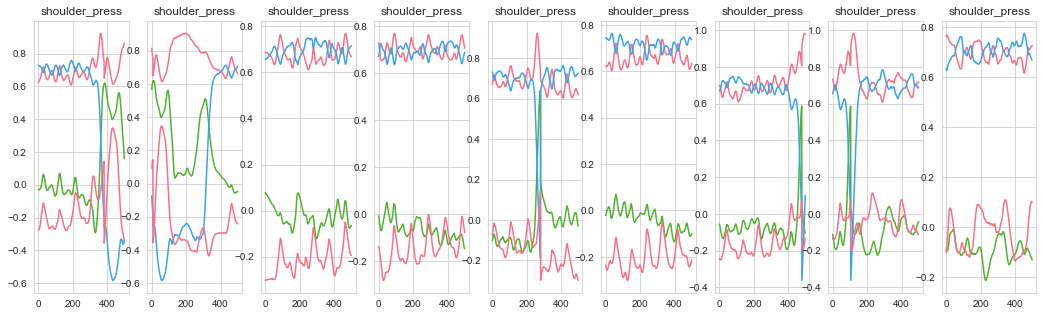

In [414]:
start_id = 300
plt.figure(figsize=(20, 5))
for i in range(1, 10):
    plt.subplot(1, 10, i)
    plt.plot(x[start_id+i])
    plt.title(y[start_id+i])
plt.show()

## Model Train

### Split into train, test, val set

In [369]:
X_train_val, X_val, y_train_val, y_val = train_test_split(x, y, test_size=0.2)
X_train, X_test, y_train, y_test = train_test_split(X_train_val, y_train_val, test_size=0.2)

In [370]:
len(np.unique(y_train))

4

In [371]:
len(np.unique(y_test))

4

In [372]:
y_train.shape, X_train.shape

((929,), (929, 500, 4))

In [373]:
y_test.shape, X_test.shape

((233,), (233, 500, 4))

In [374]:
y_val.shape, X_val.shape

((291,), (291, 500, 4))

### Convert to one hot encoding

In [375]:
class_names = np.unique(y_train)
num_classes = len(np.unique(y_train))
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert text labels into numeric identifiers
y_train_encoded = label_encoder.fit_transform(y_train)

# Convert numeric labels into one-hot
y_train_one_hot = to_categorical(y_train_encoded)


# Convert text labels into numeric identifiers
y_val_encoded = label_encoder.fit_transform(y_val)


# Convert numeric labels into one-hot
y_val_one_hot = to_categorical(y_val_encoded)

# Convert text labels into numeric identifiers
y_test_encoded = label_encoder.fit_transform(y_test)

# Convert numeric labels into one-hot
y_test_one_hot = to_categorical(y_test_encoded)

# To be used in inference script. Here print correspondence between class name and ID

In [376]:
mapping = dict(zip(label_encoder.classes_, range(0, len(label_encoder.classes_)+1)))
print(mapping)


{'curl': 0, 'front_raise': 1, 'non_exersice': 2, 'shoulder_press': 3}


## Debug input for inference testing

In [377]:
np.set_printoptions(threshold=np.inf, linewidth=700)
#X_test[0]
#np.save('model_input.npy', X_test[0])

### Define model

In [378]:
# Define the model
inputs = tf.keras.Input(shape=(sample_length, 4))

# Apply Dense layers to the inputs
layer = keras.layers.Dense(128, activation=tf.nn.relu6)(inputs)
layer = keras.layers.Dropout(0.5)(layer)
layer = keras.layers.Dense(64, activation=tf.nn.relu6)(layer)
layer = keras.layers.Dropout(0.5)(layer)

# Add GlobalAveragePooling1D to reduce dimensionality
layer = keras.layers.GlobalAveragePooling1D()(layer)

# Final layer for classification
outputs = keras.layers.Dense(len(np.unique(y_train)), activation="softmax")(layer)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_13 (InputLayer)       [(None, 500, 4)]          0         
                                                                 
 dense_36 (Dense)            (None, 500, 128)          640       
                                                                 
 dropout_24 (Dropout)        (None, 500, 128)          0         
                                                                 
 dense_37 (Dense)            (None, 500, 64)           8256      
                                                                 
 dropout_25 (Dropout)        (None, 500, 64)           0         
                                                                 
 global_average_pooling1d_12  (None, 64)               0         
  (GlobalAveragePooling1D)                                       
                                                          

### Train model

In [379]:
adamopt = tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-8)

model.compile(
    optimizer="adam",
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Add a checkpoint callback to store the checkpoint that has the highest
# validation accuracy.
checkpoint_path = "weights.best.hdf5"
checkpoint = keras.callbacks.ModelCheckpoint(checkpoint_path,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True,
                             mode='max')
earlystopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', 
                                              patience=50)

# Start training
print(X_train.shape)
history = model.fit(X_train, y_train_one_hot,
                    epochs=200,
                    batch_size=16,
                    validation_data=(X_val, y_val_one_hot),
                    callbacks=[checkpoint, earlystopping],
                    )

(929, 500, 4)
Epoch 1/200
57/59 [===========================>..] - ETA: 0s - loss: 1.1080 - accuracy: 0.5691
Epoch 1: val_accuracy improved from -inf to 0.79381, saving model to weights.best.hdf5
59/59 [==============================] - 3s 35ms/step - loss: 1.1047 - accuracy: 0.5694 - val_loss: 0.7576 - val_accuracy: 0.7938
Epoch 2/200
57/59 [===========================>..] - ETA: 0s - loss: 0.6615 - accuracy: 0.7599
Epoch 2: val_accuracy improved from 0.79381 to 0.79725, saving model to weights.best.hdf5
59/59 [==============================] - 2s 36ms/step - loss: 0.6668 - accuracy: 0.7578 - val_loss: 0.5304 - val_accuracy: 0.7973
Epoch 3/200
57/59 [===========================>..] - ETA: 0s - loss: 0.5376 - accuracy: 0.7741
Epoch 3: val_accuracy improved from 0.79725 to 0.82131, saving model to weights.best.hdf5
59/59 [==============================] - 2s 34ms/step - loss: 0.5349 - accuracy: 0.7750 - val_loss: 0.4844 - val_accuracy: 0.8213
Epoch 4/200
58/59 [=========================

Epoch 29/200
57/59 [===========================>..] - ETA: 0s - loss: 0.2553 - accuracy: 0.9178
Epoch 29: val_accuracy did not improve from 0.92440
59/59 [==============================] - 2s 32ms/step - loss: 0.2537 - accuracy: 0.9182 - val_loss: 0.2459 - val_accuracy: 0.9175
Epoch 30/200
57/59 [===========================>..] - ETA: 0s - loss: 0.2947 - accuracy: 0.8925
Epoch 30: val_accuracy did not improve from 0.92440
59/59 [==============================] - 2s 34ms/step - loss: 0.2965 - accuracy: 0.8924 - val_loss: 0.2504 - val_accuracy: 0.9244
Epoch 31/200
58/59 [============================>.] - ETA: 0s - loss: 0.2535 - accuracy: 0.9203
Epoch 31: val_accuracy did not improve from 0.92440
59/59 [==============================] - 2s 36ms/step - loss: 0.2541 - accuracy: 0.9193 - val_loss: 0.2592 - val_accuracy: 0.9072
Epoch 32/200
58/59 [============================>.] - ETA: 0s - loss: 0.2681 - accuracy: 0.9095
Epoch 32: val_accuracy did not improve from 0.92440
59/59 [===========

57/59 [===========================>..] - ETA: 0s - loss: 0.1970 - accuracy: 0.9320
Epoch 58: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 33ms/step - loss: 0.1961 - accuracy: 0.9322 - val_loss: 0.1978 - val_accuracy: 0.9381
Epoch 59/200
57/59 [===========================>..] - ETA: 0s - loss: 0.1943 - accuracy: 0.9320
Epoch 59: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 35ms/step - loss: 0.1924 - accuracy: 0.9333 - val_loss: 0.2024 - val_accuracy: 0.9347
Epoch 60/200
58/59 [============================>.] - ETA: 0s - loss: 0.1939 - accuracy: 0.9332
Epoch 60: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 35ms/step - loss: 0.1937 - accuracy: 0.9333 - val_loss: 0.1956 - val_accuracy: 0.9381
Epoch 61/200
57/59 [===========================>..] - ETA: 0s - loss: 0.1888 - accuracy: 0.9353
Epoch 61: val_accuracy did not improve from 0.94158
59/59 [========================

59/59 [==============================] - 2s 38ms/step - loss: 0.1687 - accuracy: 0.9451 - val_loss: 0.1873 - val_accuracy: 0.9416
Epoch 88/200
57/59 [===========================>..] - ETA: 0s - loss: 0.1671 - accuracy: 0.9430
Epoch 88: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 30ms/step - loss: 0.1658 - accuracy: 0.9440 - val_loss: 0.1830 - val_accuracy: 0.9347
Epoch 89/200
58/59 [============================>.] - ETA: 0s - loss: 0.1685 - accuracy: 0.9461
Epoch 89: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 33ms/step - loss: 0.1687 - accuracy: 0.9462 - val_loss: 0.1765 - val_accuracy: 0.9313
Epoch 90/200
58/59 [============================>.] - ETA: 0s - loss: 0.1788 - accuracy: 0.9364
Epoch 90: val_accuracy did not improve from 0.94158
59/59 [==============================] - 2s 38ms/step - loss: 0.1786 - accuracy: 0.9365 - val_loss: 0.1783 - val_accuracy: 0.9347
Epoch 91/200
58/59 [================

### Plot graph

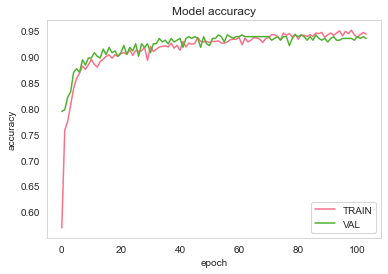

In [380]:
# Visualize the training history to see whether you're overfitting.
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['TRAIN', 'VAL'], loc='lower right')
plt.grid()
plt.show()

### Plot confusion matrix

In [381]:
loss, accuracy = model.evaluate(X_test, y_test_one_hot)

8/8 [==============================] - 0s 13ms/step - loss: 0.2054 - accuracy: 0.9227


8/8 [==============================] - 0s 27ms/step
Confusion matrix, without normalization


/var/folders/c5/xpfx3gxx5d34j23111nbtn000000gn/T/ipykernel_60673/1767718340.py:14: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar()



Classification Report:
                 precision    recall  f1-score   support

          curl       0.98      0.80      0.88        55
   front_raise       0.83      0.91      0.87        22
  non_exersice       0.89      0.96      0.93       114
shoulder_press       1.00      0.98      0.99        42

      accuracy                           0.92       233
     macro avg       0.93      0.91      0.92       233
  weighted avg       0.93      0.92      0.92       233



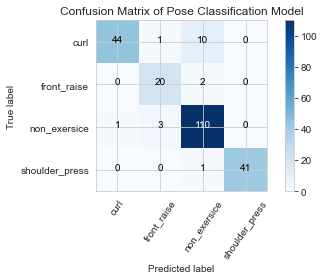

In [415]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  """Plots the confusion matrix."""
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=55)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
              horizontalalignment="center",
              color="white" if cm[i, j] > thresh else "black")

  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.tight_layout()

# Classify pose in the TEST dataset using the trained model
y_pred = model.predict(X_test)

# Convert the prediction result to class name
y_pred_label = [class_names[i] for i in np.argmax(y_pred, axis=1)]
y_true_label = [class_names[i] for i in np.argmax(y_test_one_hot, axis=1)]

# Plot the confusion matrix
cm = confusion_matrix(np.argmax(y_test_one_hot, axis=1), np.argmax(y_pred, axis=1))
plot_confusion_matrix(cm,
                      class_names,
                      title ='Confusion Matrix of Pose Classification Model')

# Print the classification report
print('\nClassification Report:\n', classification_report(y_true_label, y_pred_label))